In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os
import joblib
from itertools import product
from scipy.signal import butter, filtfilt

import matplotlib.ticker as mticker
import pandas as pd
import control as ctl

In [2]:
df   = pd.read_csv('../Dataset/data.csv')
X_MIN, X_MAX = (0.7, 0.8)
INPUT  = 'actuator'
SENSOR = 'sensor'

In [3]:
df = df.rename(columns={INPUT: 'input', SENSOR: 'sensor'})
df

,input,sensor,time
0,255,1008,2.160
1,255,821,2.175
2,255,699,2.190
3,255,495,2.250
4,255,472,2.265
...,...,...,...
2299,122,509,99.855
2300,122,456,99.900
2301,122,481,99.945
2302,122,467,99.990


In [4]:
ACTUATOR_RANGE = (0, 255)
SENSOR_RANGE   = (400, 900)

print('actuator range:', ACTUATOR_RANGE)
print('sensor range:  ', SENSOR_RANGE)

actuator range: (0, 255)
sensor range:   (400, 900)


Text(0, 0.5, 'sensor')

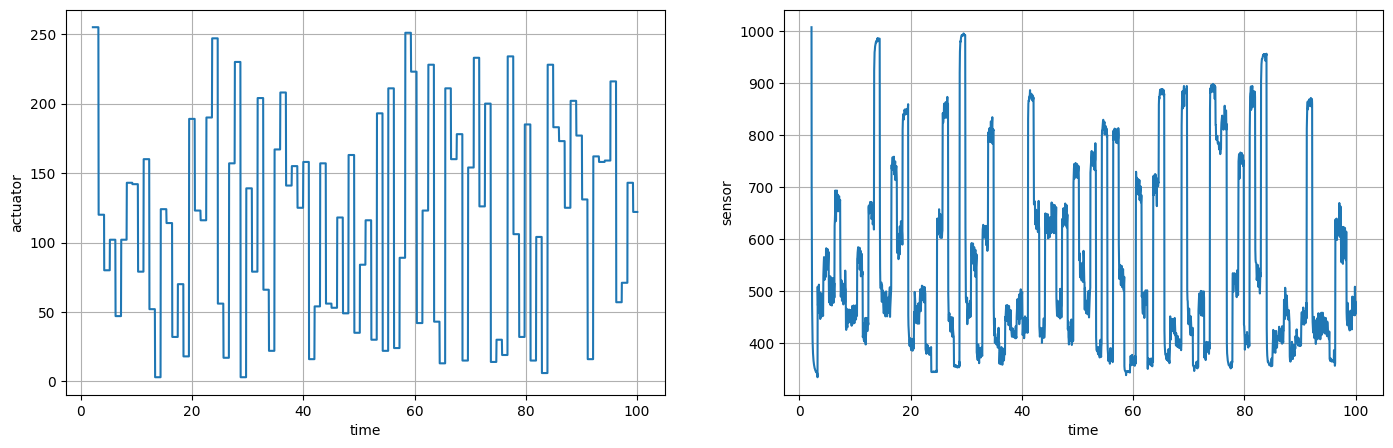

In [5]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.input)
plt.grid()
plt.xlabel('time'); plt.ylabel(INPUT)

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel(SENSOR)

Text(0, 0.5, 'sensor')

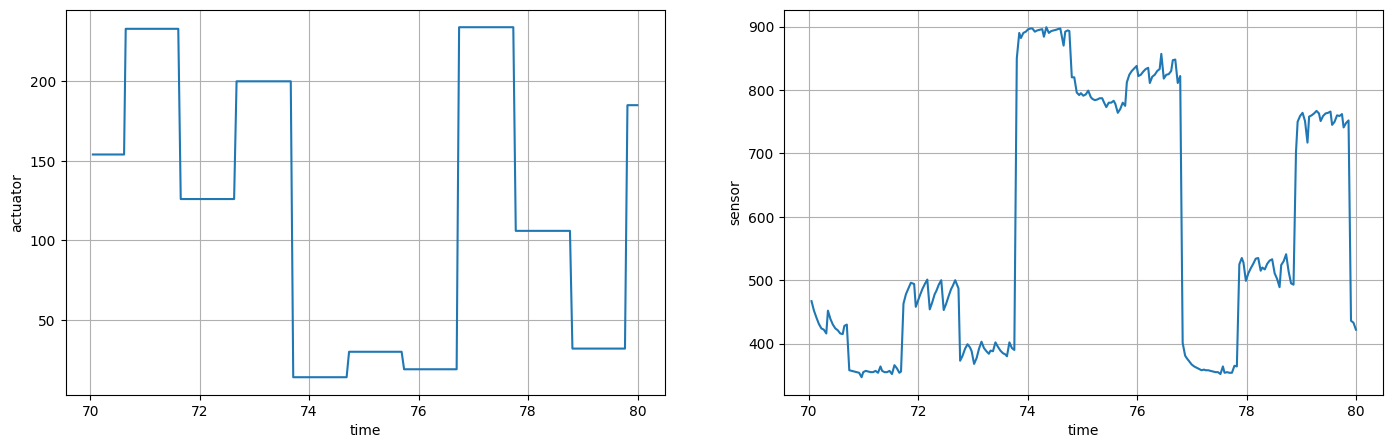

In [6]:
target = df.loc[(df.time > df.time.max()*X_MIN) & (df.time < df.time.max()*X_MAX)]

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(target.time, target.input)
plt.grid()
plt.xlabel('time'); plt.ylabel(INPUT)

plt.subplot(1, 2, 2)
plt.plot(target.time, target.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel(SENSOR)

0.045


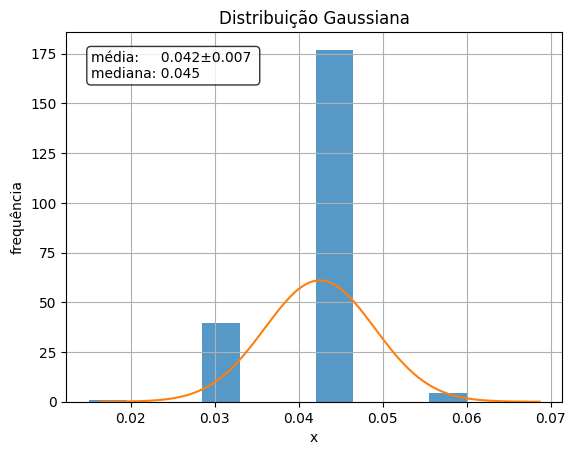

In [7]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(3)
print(dt)
gaussian(time)

In [8]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)

    target = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,input,sensor
0,0.000,255,1008
1,0.045,255,699
2,0.090,255,495
3,0.135,255,472
4,0.180,255,429
...,...,...,...
2172,97.740,122,509
2173,97.785,122,481
2174,97.830,122,467
2175,97.875,122,458


Text(0, 0.5, 'sensor')

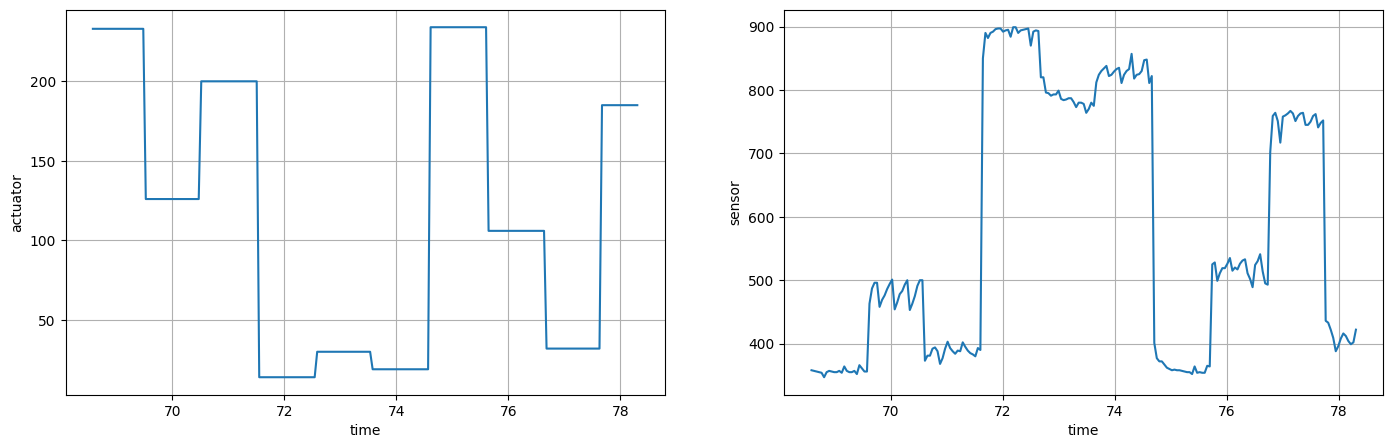

In [9]:
target = df.loc[(df.time > df.time.max()*X_MIN) & (df.time < df.time.max()*X_MAX)]

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(target.time, target.input)
plt.grid()
plt.xlabel('time'); plt.ylabel(INPUT)

plt.subplot(1, 2, 2)
plt.plot(target.time, target.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel(SENSOR)

In [10]:
class FrequencyAnalyzer:
    def __init__(self, xData, yData):
        self.xData = np.asarray(xData)
        self.yData = np.asarray(yData)
        
        self.dt = np.mean(np.diff(self.xData))
        self.nSamples = len(self.yData)
        
        self.yFreq = None
        self.yMag  = None

    def update(self):
        fftResult  = np.fft.fft(self.yData)
        freqs      = np.fft.fftfreq(self.nSamples, self.dt)
        self.yFreq = np.fft.fftshift(freqs)
        self.yMag  = np.fft.fftshift(np.abs(fftResult)) / self.nSamples

    def plot(self, xLim=None, yLim=None, Fc=None):
        self.update()

        plt.plot(self.yFreq, self.yMag, label='blue', color='red', alpha=0.5)

        if Fc is not None:
            yMagRestricted = self.yMag.copy()
            allowed = (np.abs(self.yFreq) <= Fc)
            yMagRestricted[~allowed] = 0
            plt.plot(self.yFreq, yMagRestricted, label=f'Fc={Fc}', color='blue')
        
        plt.xlabel('frequency')
        plt.ylabel('amplitude')
        plt.grid(alpha=0.3)
        
        if xLim: plt.xlim(xLim)
        if yLim: plt.ylim(yLim)
        plt.legend()


class LowPassFilter:
    def __init__(self, Fc, dt):
        self.dt = dt
        self.Fc = Fc
        
        Wc = (2 * np.pi * Fc) 
        s  = ctl.TransferFunction.s
        
        H   = Wc / (s + Wc)
        H_z = ctl.c2d(H, dt, method='tustin')
        
        self.num, self.den = self.getFraction(H_z)
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))

    def getFraction(self, G_z):
        num, den = ctl.tfdata(G_z)
        num = np.squeeze(num)
        den = np.squeeze(den)

        num = num / den[0]
        den = den / den[0]
        return num.tolist(), den.tolist()

    def compute(self):
        out = 0.0
        for i in range(len(self.num)):
            out += self.Xn[i] * self.num[i]
        
        for i in range(1, len(self.den)):
            out -= self.Yn[i] * self.den[i]

        return out

    def update(self, inputValue):
        for n in range(len(self.num)-1, 0, -1):
            self.Xn[n] = self.Xn[n-1]

        for n in range(len(self.den)-1, 0, -1):
            self.Yn[n] = self.Yn[n-1]
        
        self.Xn[0] = inputValue
        self.Yn[0] = self.compute()
        return self.Yn[0] if self.Fc > 0 else inputValue

    def apply(self, yData):
        self.Xn = np.zeros(len(self.num))
        self.Yn = np.zeros(len(self.den))
        return np.array([self.update(val) for val in yData])

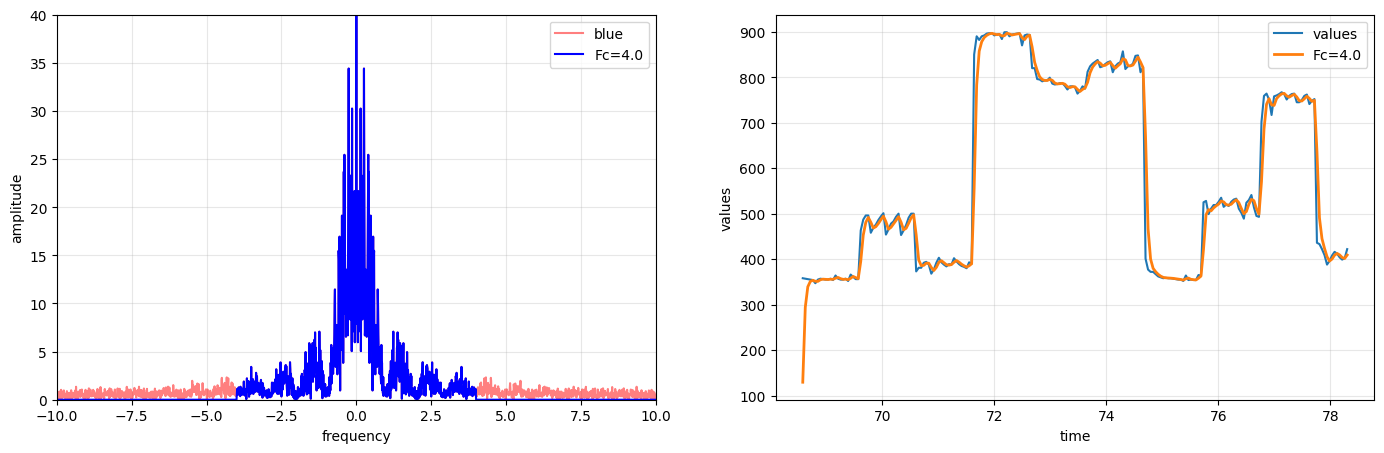

In [11]:
Fc = 4.0
xLim = (-10, 10)
yLim = (0, 40)

plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
FrequencyAnalyzer(df.time, df.sensor).plot(xLim, yLim, Fc=Fc)

plt.subplot(1, 2, 2)
target = df.loc[(df.time > df.time.max()*X_MIN) & (df.time < df.time.max()*X_MAX)]
ft     = LowPassFilter(Fc=Fc, dt=dt)
plt.plot(target.time, target.sensor, label='values')
plt.plot(target.time, ft.apply(target.sensor), label=f'Fc={Fc}', linewidth=2)
plt.grid(alpha=0.3); plt.legend()
plt.xlabel('time'); plt.ylabel('values')
plt.show()

In [12]:
df['sensor'] = LowPassFilter(Fc=Fc, dt=dt).apply(df.sensor)
df.head()

,time,input,sensor
0,0.000,255,364.110777
1,0.045,255,717.666115
2,0.090,255,630.491843
3,0.135,255,524.298759
4,0.180,255,470.983435


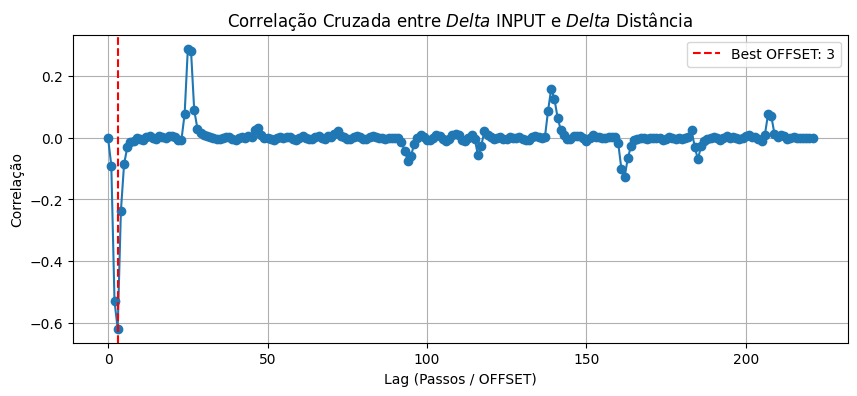

In [13]:
def getOffset(df, input_col=INPUT, output_col=SENSOR, max_lag=30):
    u_diff = df[input_col].diff().fillna(0)
    y_diff = df[output_col].diff().fillna(0)

    lags = np.arange(0, max_lag)
    correlations = []

    for lag in lags:
        corr = u_diff.corr(y_diff.shift(-lag))
        correlations.append(corr if not np.isnan(corr) else 0)

    best_lag = lags[np.argmax(np.abs(correlations))]
    plt.figure(figsize=(10, 4))
    plt.plot(lags, correlations, marker='o')
    plt.axvline(best_lag, color='red', linestyle='--', label=f'Best OFFSET: {best_lag}')
    plt.title('Correlação Cruzada entre $Delta$ INPUT e $Delta$ Distância')
    plt.xlabel('Lag (Passos / OFFSET)')
    plt.ylabel('Correlação')
    plt.grid()
    plt.legend()
    plt.show()
    return int(best_lag)


max_time = 10
max_lag  = int(max_time/dt)
OFFSET   = getOffset(df, 'input', 'sensor', max_lag) 

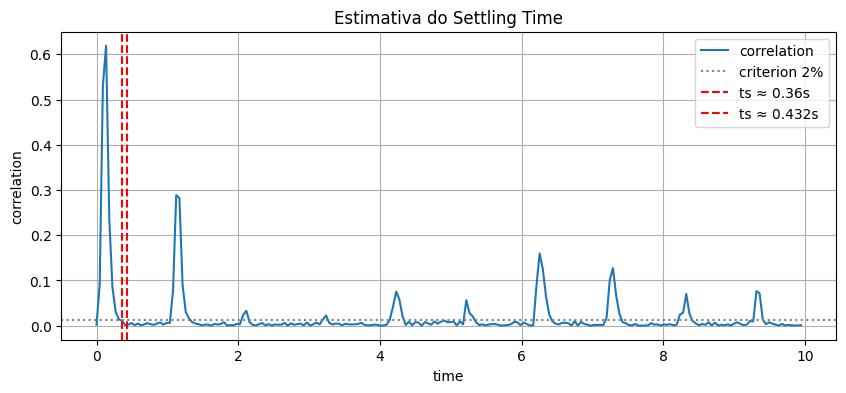

np.float64(0.432)

In [14]:
def getSettlingTime(df, input_col, output_col, dt, max_time=15, criterion=0.02):
    max_lag = int(max_time / dt)
    u_diff = df[input_col].diff().fillna(0)
    y_diff = df[output_col].diff().fillna(0)

    lags = np.arange(0, max_lag)
    corr = np.array([c if not np.isnan(c := u_diff.corr(y_diff.shift(-lag))) else 0 for lag in lags])

    envelope  = np.abs(corr)
    peak_val  = envelope.max()
    threshold = (peak_val * criterion)

    window = 5
    for i in range(np.argmax(envelope), len(envelope) - window):
        if all(envelope[i:i + window] < threshold):
            ts = round(i * dt, 3)

            plt.figure(figsize=(10, 4))
            plt.plot(lags * dt, envelope, label='correlation')
            plt.axhline(threshold, color='gray', linestyle=':', label=f'criterion {criterion*100:.0f}%')
            
            plt.axvline(ts, color='red', linestyle='--', label=f'ts ≈ {ts}s')
            plt.axvline(1.2*ts, color='red', linestyle='--', label=f'ts ≈ {ts*1.2}s')
            plt.xlabel('time'); plt.ylabel('correlation')
            plt.title('Estimativa do Settling Time')
            plt.grid(); plt.legend(); plt.show()
            return ts*1.2
    
    return round(max_lag * dt, 3)

ts = getSettlingTime(df, 'input', 'sensor', dt, max_time=10, criterion=0.02)
ts

In [15]:
info = {
    'dt': dt,
    'offset': OFFSET, 
    'view_range': [X_MIN, X_MAX],
    'sensor_range': list(SENSOR_RANGE),
    'actuator_range': list(ACTUATOR_RANGE),
    'sensor_filter': {'num': ft.num, 'den': ft.den},
    'Fc': Fc,
    'ts': ts
}

with open('info.json', 'w', encoding='utf-8') as file:
    json.dump(info, file, ensure_ascii=False, indent=4)

In [16]:
df.to_csv('../Dataset/data_cleaned.csv', index=None)